In [1]:
import pandas as pd
import numpy as np
import pingouin as pg
from sklearn.decomposition import PCA
from PersonaClassifier import My_training, Dataset, generate_cal_result
import shap
shap.initjs()

In [2]:
demo = 1000
my_train = My_training(models=['mlp'], emb_model='openai')
dataset = Dataset('./data/pandora_to_big5_openai_embedded_1000.csv', my_train.emb_model, my_train.traits, demo) 
selected_features = {}
hyperparameters = {
        'hidden_dim' : 256,
        'batch_size': 16,
        'epochs': 32,
        'learning_rate': 0.0001,
        'dropout_rate': 0.3,
    }


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

PermutationExplainer explainer: 101it [25:59, 15.60s/it]                         


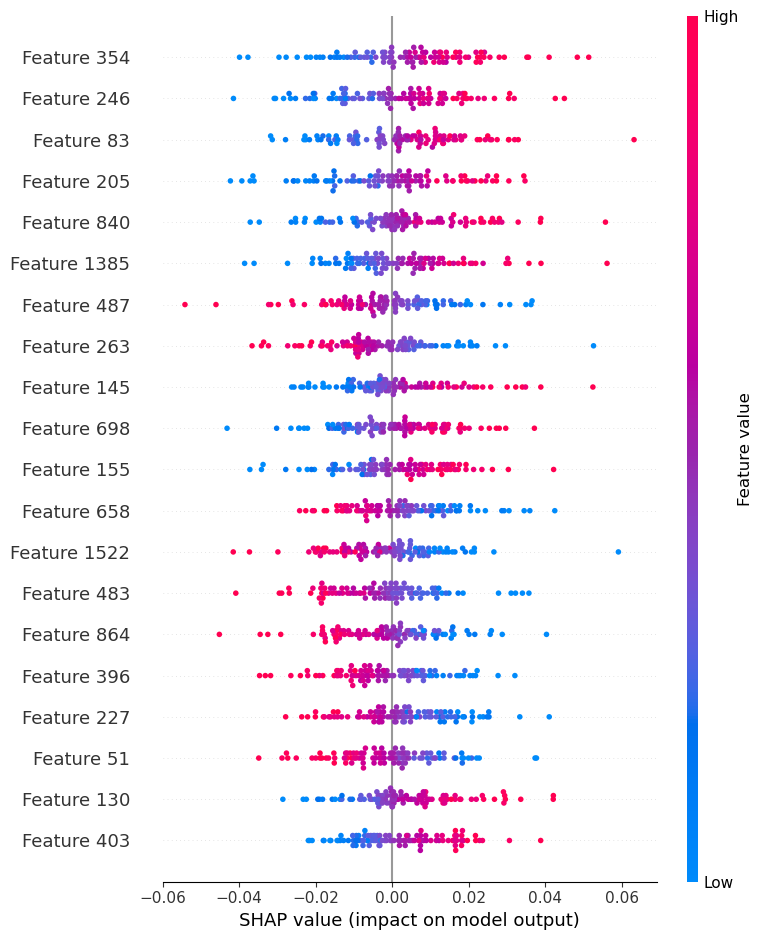

In [31]:
#Explaining  Embedding
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
my_train.models = ['mlp']
for target_col in ['cOPN']:
    X, Z, y = dataset.X, dataset.contextual_emb, dataset.Y[[target_col]]
    
    Z, y= np.array(Z), np.array(y).ravel()
    Z_train, Z_test, y_train, y_test, = train_test_split(Z, y, stratify=y, test_size=0.1, shuffle=True, random_state=42)

    my_train.init_models(X_shape=Z.shape[1], kFold=False, hyperparameters=hyperparameters)
    my_train.fit(Z, y, target_col, save_ckpt=False)

    explainer = shap.Explainer(my_train.estimators['mlp'].predict_proba, Z_train)
    shap_values = explainer.shap_values(Z_test)  # Use first 100 samples
    shap.summary_plot(shap_values[:, :, 1], Z_test)

In [90]:
sv = np.abs(shap_values[:, :, 1]).mean(axis=0)  # Use the first class for binary classification
top_feature_indices = np.argsort(sv)[::-1]  
top_k_dim = top_feature_indices[:100]
emb_df, Y = dataset.contextual_emb, dataset.Y
# emb_df = emb_df[top_k_dim]
filtered_y = Y[Y['cOPN'] == 1]
filtered_indices = filtered_y.index
filtered_emb_df = emb_df.iloc[filtered_indices] 
filtered_emb_df

,0,1,2,3,4,5,6,7,8,9,...,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535
58,-0.018201,-0.029043,-0.014876,-0.009462,-0.007241,-0.006439,0.015494,-0.023970,0.014495,-0.013207,...,-0.013746,0.036613,0.011578,0.005556,-0.005191,0.001616,0.029753,-0.004603,0.004123,-0.000554
155,0.035240,0.004298,-0.006351,0.014324,0.050033,-0.017044,0.020822,0.033525,0.001757,-0.024976,...,-0.005665,-0.000361,-0.014136,0.013104,0.003681,0.029398,-0.013017,-0.004107,0.018880,0.041940
908,0.028416,0.032261,0.018027,0.031813,0.043006,0.000590,0.060098,0.008783,-0.004326,0.009876,...,-0.003285,-0.013155,-0.010146,0.009876,0.005122,-0.029311,0.037870,0.009652,-0.010389,0.024532
83,-0.053503,0.017512,-0.045150,0.036743,0.026564,-0.039402,0.014732,-0.020695,0.033225,-0.014410,...,0.011885,-0.031801,-0.018466,-0.009562,0.023730,0.009193,0.012946,0.027007,-0.018654,0.005610
375,-0.008505,0.051648,0.045285,0.028671,-0.035777,0.022605,0.005982,-0.007044,0.045706,-0.027483,...,-0.051697,-0.009105,-0.021838,-0.026517,-0.001098,0.000278,-0.007403,0.000322,-0.015351,-0.010151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,0.028665,-0.015708,-0.004984,0.081402,0.008239,0.000520,0.032526,0.008668,0.022369,0.020616,...,-0.028185,-0.000424,-0.011222,-0.008825,-0.022899,-0.003719,0.039414,-0.020716,-0.056169,0.006693
172,0.015298,0.006181,-0.080166,0.033464,0.036724,-0.015702,0.026011,0.054277,0.014979,-0.001852,...,-0.023927,0.001616,-0.012203,-0.021218,0.022567,0.027384,0.009549,-0.008066,0.026820,0.014930
361,0.037307,-0.025664,-0.013120,-0.012400,0.056609,-0.033514,0.012262,0.015677,0.001190,-0.032770,...,0.019890,0.005183,-0.025591,0.005044,-0.044845,0.015617,0.010827,0.011601,0.023659,0.017345
504,0.022687,0.030413,-0.005655,0.036767,-0.010339,0.006649,0.058653,0.040813,-0.027833,-0.031146,...,-0.005417,-0.003561,0.017867,-0.013917,-0.005862,0.023678,0.024479,0.004233,0.000989,0.027969


In [99]:
from pingouin import cronbach_alpha
alpha = cronbach_alpha(filtered_emb_df[top_feature_indices[:1500]])
print(f'Cronbach’s alpha for : {alpha}')

Cronbach’s alpha for : (-0.17253083771318334, array([-0.318, -0.036]))


In [ ]:
from pingouin import cronbach_alpha
for factor in shap.columns:
    items = factor_loadings[factor].abs().nlargest(10).index  # Top 10 items per factor
    alpha = cronbach_alpha(reduced_embedding_df[items])
    print(f'Cronbach’s alpha for {factor}: {alpha}')

In [3]:

df = pd.read_csv('data/pandora_to_big5_openai_embedded_1000.csv')
s = df.sample(1000, random_state=42)
s = s[['body', 'agreeableness', 'openness', 'conscientiousness', 'extraversion', 'neuroticism', 'openai_embedding']]
s = s.dropna()
s

,body,agreeableness,openness,conscientiousness,extraversion,neuroticism,openai_embedding
521,"As an exercise, I think the idea is just that ...",70.0,65.0,61.0,14.0,80.0,"[-0.001847649342380464, -0.028040168806910515,..."
737,"I've accepted ""just met"" dates on dating websi...",91.0,90.0,20.0,43.0,73.0,"[-0.021999415010213852, -0.047251466661691666,..."
740,Thank you. I love this sub so much. So many pe...,86.0,84.0,9.0,80.0,93.0,"[0.05048408731818199, -0.006028835661709309, -..."
660,Standing strong and not immediately caving on ...,60.0,73.0,42.0,40.0,72.0,"[-0.014242257922887802, -0.008402043953537941,..."
411,"By 'spiritbonded' people generally mean 100%, ...",15.0,14.0,35.0,18.0,44.0,"[-0.007035932037979364, 0.06255399435758591, 0..."
...,...,...,...,...,...,...,...
106,"Tell tale signs abound. Typically, they will ...",13.0,17.0,55.0,24.0,33.0,"[0.009993987157940865, 0.0503271259367466, -0...."
270,Yes. Well Socionics is not a unified study. ...,70.0,92.0,81.0,7.0,5.0,"[-0.03612933307886124, -0.006419937591999769, ..."
860,Didn't you get the memo that kid germs are wid...,57.0,80.0,86.0,79.0,55.0,"[0.00542834447696805, 0.0056680720299482346, -..."
435,I think it's less about the attraction and mor...,79.0,59.0,89.0,19.0,54.0,"[-0.009434251114726067, -0.021807357668876648,..."


In [4]:
s['openai_embedding'] = s['openai_embedding'].apply(eval).apply(np.array)
embedding_df = pd.DataFrame(s['openai_embedding'].tolist())
embedding_df.columns = [f'emb_{i}' for i in range(embedding_df.shape[1])]
# embeddings = embedding_df.filter(like='emb_').values  # Extract embedding columns
pca = PCA(n_components=5)  # Reduce to 10 dimensions
reduced_embeddings = pca.fit_transform(embedding_df)
reduced_embedding_df = pd.DataFrame(reduced_embeddings)
reduced_embedding_df.columns = [f'pca_{i}' for i in range(reduced_embedding_df.shape[1])]
reduced_embedding_df
correlations = reduced_embedding_df.corr()
import seaborn as sns
sns.heatmap(correlations, annot=True, cmap="Reds", linewidths=0.5)
# Calculate Cronbach's alpha for the reduced dimensions
alpha_embeddings = pg.cronbach_alpha(reduced_embedding_df[['pca_1', 'pca_3', 'pca_4']])
print(f'Cronbach\'s alpha for Embeddings: {alpha_embeddings}')

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_1526,emb_1527,emb_1528,emb_1529,emb_1530,emb_1531,emb_1532,emb_1533,emb_1534,emb_1535
0,-0.001848,-0.028040,0.013266,0.008429,0.075115,0.010250,0.027187,0.008088,-0.036533,0.019334,...,0.009311,-0.035765,-0.020130,-0.003845,-0.004012,-0.008522,-0.006647,-0.011161,0.019063,0.035566
1,-0.021999,-0.047251,-0.013704,0.056127,0.007363,-0.055169,-0.012361,-0.028618,0.026828,0.093696,...,-0.015229,0.011958,-0.007028,0.022831,0.028543,0.028896,0.019995,0.022705,-0.017310,0.021836
2,0.050484,-0.006029,-0.047914,0.079620,0.004354,-0.021763,-0.035125,0.004475,0.034058,0.004900,...,-0.008732,0.013293,0.014598,-0.001580,-0.014795,0.013451,0.005100,-0.013036,-0.040324,0.021447
3,-0.014242,-0.008402,0.013342,0.040862,0.016018,0.017679,-0.015257,0.000332,0.052556,0.016284,...,-0.023323,-0.010165,0.012093,0.018098,0.023703,-0.002039,0.037743,-0.017996,-0.025530,-0.007020
4,-0.007036,0.062554,0.017310,0.044618,-0.018535,0.035483,0.000228,0.022880,0.064169,0.001722,...,0.013501,-0.017449,-0.011147,-0.045593,-0.025749,-0.035455,0.003321,-0.010180,-0.025554,-0.002576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.009994,0.050327,-0.037293,0.055780,0.055197,-0.023676,-0.037906,0.062690,0.026826,0.051435,...,0.001104,0.018399,0.010322,-0.010060,-0.014718,0.003198,0.007727,-0.002748,0.000914,-0.008835
996,-0.036129,-0.006420,-0.032040,0.004879,0.002193,0.004107,0.041883,0.013601,-0.001964,0.004287,...,-0.026695,0.048567,-0.048201,0.000379,0.006949,0.018713,0.031617,-0.028585,0.006794,0.034804
997,0.005428,0.005668,-0.079130,0.069619,-0.023487,-0.020846,0.018640,0.013123,-0.023920,0.026836,...,-0.022607,-0.005570,-0.022974,-0.014948,0.010784,0.057692,0.032156,0.007619,-0.015723,0.031736
998,-0.009434,-0.021807,-0.022640,0.063406,0.052509,-0.017412,0.037009,-0.042418,-0.019350,-0.010058,...,-0.036229,0.016450,-0.020702,-0.009005,0.026658,0.014538,0.001172,0.026307,-0.005666,0.041534


In [ ]:
pca = PCA(n_components=5)  # Reduce to 10 dimensions
reduced_embeddings = pca.fit_transform(embedding_df)
reduced_embedding_df = pd.DataFrame(reduced_embeddings)
reduced_embedding_df.columns = [f'pca_{i}' for i in range(reduced_embedding_df.shape[1])]
reduced_embedding_df

In [103]:
from factor_analyzer import FactorAnalyzer
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(embedding_df)
loadings = fa.loadings_
print(loadings)

In [98]:
reduced_embedding_df['openness'] = df['openness']
reduced_embedding_df['conscientiousness'] = df['conscientiousness']
reduced_embedding_df = pd.DataFrame(scaler.fit_transform(reduced_embedding_df), columns=reduced_embedding_df.columns)
reduced_embedding_df

,pca_0,pca_1,pca_2,pca_3,pca_4,openness,conscientiousness
0,0.136058,-0.218958,0.047063,-0.047708,-0.079159,70.0,15.0
1,-0.091530,-0.057014,0.024694,0.104257,-0.000186,70.0,15.0
2,-0.150703,-0.106461,0.049721,0.095037,-0.015605,70.0,15.0
3,-0.194421,0.117509,-0.253391,0.127293,-0.071977,70.0,15.0
4,0.001678,-0.152691,-0.005446,0.342288,0.060985,70.0,15.0
...,...,...,...,...,...,...,...
4995,0.033733,0.191957,0.223647,0.014393,-0.178396,73.0,73.0
4996,-0.204098,-0.066269,0.071500,0.025241,-0.017655,73.0,73.0
4997,-0.021210,-0.207306,0.095187,-0.091617,0.217196,73.0,73.0
4998,0.263440,0.142681,-0.084221,0.005711,0.144310,73.0,73.0


In [ ]:
import pandas as pd
import pingouin as pg

# Load your data
data = pd.read_csv('your_data.csv')

# Example: Calculate Cronbach's alpha for 'openness' (assuming multiple items)
# Replace 'openness_1', 'openness_2', etc., with your actual column names
openness_items = data[['openness_1', 'openness_2', 'openness_3']]
alpha_openness = pg.cronbach_alpha(openness_items)
print(f'Cronbach\'s alpha for Openness: {alpha_openness}')

# Repeat for other traits
conscientiousness_items = data[['conscientiousness_1', 'conscientiousness_2', 'conscientiousness_3']]
alpha_conscientiousness = pg.cronbach_alpha(conscientiousness_items)
print(f'Cronbach\'s alpha for Conscientiousness: {alpha_conscientiousness}')

In [4]:
from typing import List
def maxProfit( prices: List[int]) -> int:
    prev = prices[0]
    buy, sell = -1, -1
    for i in range(1, len(prices)):
        if prices[i] < prev:
            buy = prices[i]
        if prices[i]  > buy and prices[i] > sell:
            sell = prices[i]
    print (buy)
    return 0 if buy == -1 else sell - buy
    
print(maxProfit([7,1,5,3,6,4]))

4
-5
